In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [2]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

C:\Users\victo\AppData\Local\Temp\ipykernel_18012\4168379563.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


In [3]:
data = data.drop(data[data["position"] == "team"].index) 

In [4]:
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)

In [5]:
data

,gameid,datacompleteness,league,year,split,playoffs,date,game,patch,participantid,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,1,...,200.0,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0
1,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,2,...,157.0,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0
2,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,3,...,241.0,-1552.0,-2465.0,-41.0,1.0,0.0,2.0,1.0,5.0,1.0
3,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,4,...,257.0,-2613.0,-1156.0,-6.0,1.0,1.0,2.0,6.0,2.0,0.0
4,LOLTMNT03_179647,complete,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,5,...,20.0,-662.0,-734.0,18.0,0.0,2.0,2.0,0.0,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118925,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,6,...,175.0,1809.0,1467.0,-12.0,5.0,1.0,4.0,1.0,4.0,7.0
118926,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,7,...,156.0,-188.0,2855.0,47.0,0.0,9.0,2.0,2.0,5.0,4.0
118927,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,8,...,236.0,787.0,888.0,-23.0,9.0,4.0,1.0,4.0,3.0,1.0
118928,LOLTMNT02_326112,complete,LAS,2025,Champ 2,1,2025-11-16 11:34:09,3,15.21,9,...,244.0,814.0,-348.0,15.0,3.0,9.0,1.0,2.0,4.0,2.0


In [ ]:
z = data["playerid"].unique()[:2]
gameids = data.loc[data["playerid"] == z[0], "gameid"]
played_with = data.loc[data["gameid"].isin(gameids), "playerid"]
print(len(gameids))
print(len(played_with))
times_played_with = len(played_with[played_with == z[1]])

61
610


38

In [79]:
data["sort"] = data['playerid'].str.extract('(\d+)', expand=False).astype(int)
data.sort_values("sort")

OverflowError: int too big to convert

In [107]:
uniq_player_ids = data["playerid"].unique()
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

In [108]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/7196 [00:00<?, ?it/s]

In [106]:
adj_matrix[0][:100]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

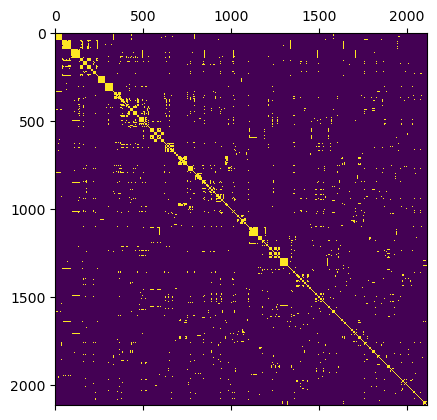

In [109]:
plt.matshow(adj_matrix)

In [81]:
z = []
#data.sort_index(key = lambda k: k["playerid"].str.extract('(\d+)', expand=False).astype(int))
for player1 in tqdm(data["playerid"].unique()):
    for player2 in data["playerid"].unique(): 
        player1_gameids = data.loc[data["playerid"] == player1, "gameid"]
        player2_gameids = data.loc[data["playerid"] == player2, "gameid"]

        z.append(len(set(player1_gameids).intersection(player2_gameids)))

        #players_player1_played_with = data.loc[data["gameid"].isin(player1_gameids), "playerid"]
        #times_player1_played_with_player2 = len(players_player1_played_with[players_player1_played_with == player2])
        #z.append(times_player1_played_with_player2)

  0%|          | 0/2118 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [75]:
data["playerid"][0][15:]

'97694306de62d978569b84c344'